# Palmer penguins data visualization

## Analysis objective

The purpose of this data analysis report is to visualize relevant variables in the Palmer Archipelago penguin dataset, in order to explore and analyze the relationships between factors such as species, sex, and island, and penguins’ physical characteristics, including body mass, culmen length, culmen depth, and flipper length.

## Introduction

The raw dataset `Penguins.csv` contains 344 penguin samples collected from three islands in the Palmer Archipelago, Antarctica. It includes several penguin-related attributes, such as species, island, culmen length, culmen depth, flipper length, body mass, and sex.

The meaning of each column in `Penguins.csv` is as follows:

- `species`: penguin species
- `island`: island where the penguin was observed
- `culmen_length_mm`: culmen length of the penguin, in millimeters
- `culmen_depth_mm`: culmen depth of the penguin, in millimeters
- `flipper_length_mm`: flipper length of the penguin, in millimeters
- `body_mass_g`: body mass of the penguin, in grams
- `sex`: penguin sex


## Load Data

Import the required libraries for data analysis and use Pandas’ `read_csv()` function to load the raw `Penguins.csv` file into a DataFrame named `original_penguins`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
original_penguins = pd.read_csv('./Penguins.csv')
original_penguins

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


## Data evaluation and cleaning

### Back up original data

In [3]:
cleaned_penguins = original_penguins.copy()

#### Data tidiness

In [4]:
cleaned_penguins.sample(10)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
161,Chinstrap,Dream,51.3,19.9,198.0,3700.0,MALE
148,Adelie,Dream,36.0,17.8,195.0,3450.0,FEMALE
29,Adelie,Biscoe,40.5,18.9,180.0,3950.0,MALE
327,Gentoo,Biscoe,53.4,15.8,219.0,5500.0,MALE
97,Adelie,Dream,40.3,18.5,196.0,4350.0,MALE
177,Chinstrap,Dream,52.0,19.0,197.0,4150.0,MALE
176,Chinstrap,Dream,46.7,17.9,195.0,3300.0,FEMALE
139,Adelie,Dream,39.7,17.9,193.0,4250.0,MALE
108,Adelie,Biscoe,38.1,17.0,181.0,3175.0,FEMALE


From a random sample of 10 rows, each column represents a variable, each row represents an observation, and each cell contains a single value. Therefore, the dataset is tidy.

#### Data quality

In [5]:
cleaned_penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


The dataset contains 344 rows and 7 columns. Columns of `culmen_length_mm`, `culmen_depth_mm`, `flipper_length_mm`, `body_mass_g` and `sex` contain missing values. The data types of all columns were checked. Since `species`, `island`, and `sex` are categorical variables with limited unique values, they could be converted to the category data type.

In [6]:
cleaned_penguins['species'] = cleaned_penguins['species'].astype("category")
cleaned_penguins['sex'] = cleaned_penguins['sex'].astype("category")
cleaned_penguins['island'] = cleaned_penguins['island'].astype("category")

In [7]:
cleaned_penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   species            344 non-null    category
 1   island             344 non-null    category
 2   culmen_length_mm   342 non-null    float64 
 3   culmen_depth_mm    342 non-null    float64 
 4   flipper_length_mm  342 non-null    float64 
 5   body_mass_g        342 non-null    float64 
 6   sex                334 non-null    category
dtypes: category(3), float64(4)
memory usage: 12.0 KB


The updated `info()` output was used to verify that the categorical variables were successfully converted to the `category` data type.


##### Missing data

Since all columns in this dataset are used in the visualization analysis, rows containing missing values should be removed to ensure complete and consistent comparisons across species, islands, sex, and body measurements.

Remove rows with missing values, and then check the remaining number of missing values in these columns.

In [8]:
cleaned_penguins.dropna(inplace = True)
cleaned_penguins.isna().sum()

species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

##### Duplicated data

Since the dataset does not include a unique penguin ID, identical records may still correspond to different individual penguins. Therefore, duplicate checking and duplicate removal were not required for this analysis.

##### Inconsistent data

Category values in the `species`, `island`, and `sex` columns were checked to identify any inconsistent or invalid entries before analysis.

In [9]:
cleaned_penguins["species"].value_counts()

species
Adelie       146
Gentoo       120
Chinstrap     68
Name: count, dtype: int64

No inconsistent values were found in the `species` column.

In [10]:
cleaned_penguins["island"].value_counts()

island
Biscoe       164
Dream        123
Torgersen     47
Name: count, dtype: int64

No inconsistent values were found in the `island` column.

In [11]:
cleaned_penguins["sex"].value_counts()

sex
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64

In [12]:
cleaned_penguins = cleaned_penguins[cleaned_penguins["sex"] != "."]
cleaned_penguins["sex"] = cleaned_penguins["sex"].cat.remove_unused_categories()

In [13]:
cleaned_penguins["sex"].value_counts()

sex
MALE      168
FEMALE    165
Name: count, dtype: int64

The `sex` column was checked for inconsistent category values. One invalid value "." was found and removed because it does not represent a valid sex category.

##### Invalid or erroneous data

In [14]:
cleaned_penguins.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


Based on the summary statistics, no obvious invalid or erroneous values were found in the numerical columns. The minimum and maximum values are within reasonable ranges, so these records were retained.

## Save cleaned data

Save the cleaned dataset in the same folder.

In [15]:
cleaned_penguins.to_csv("cleaned_penguins.csv", index = False)

Read the saved file to verify that it was exported successfully.

In [16]:
pd.read_csv("./cleaned_penguins.csv")

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...,...,...
328,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE
329,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
330,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
331,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


## Data visualization

The color palette was first adjusted to `Set2` for a softer visualization style.

In [17]:
sns.set_palette("Set2")

### Sample distribution

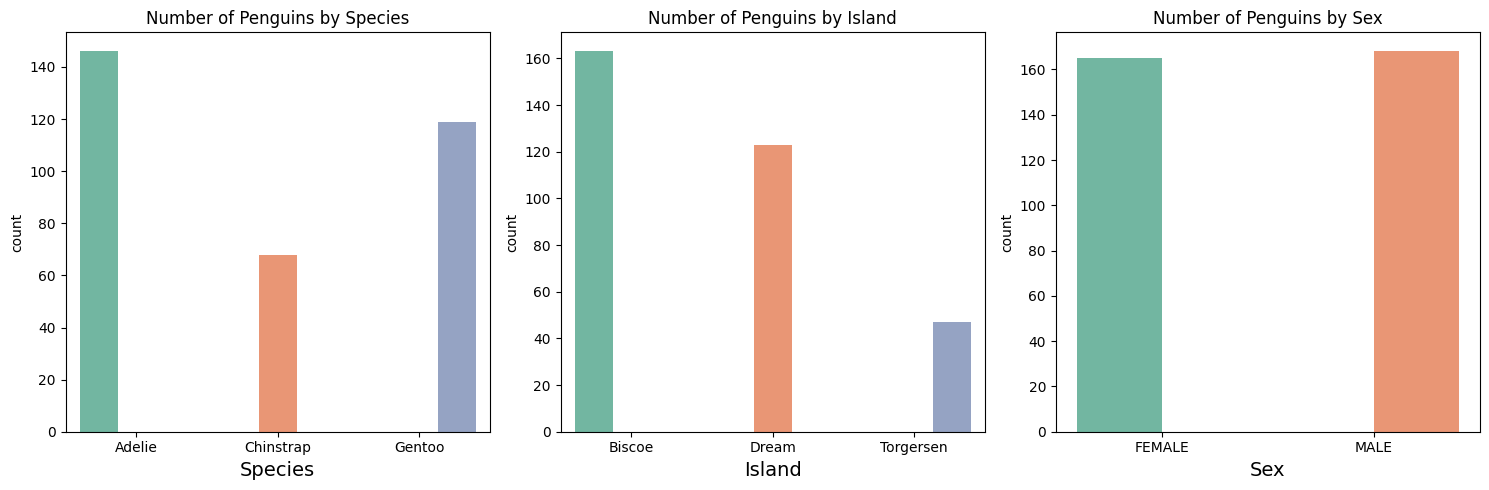

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.countplot(cleaned_penguins, x="species", hue="species", ax=axes[0])
sns.countplot(cleaned_penguins, x="island", hue="island", ax=axes[1])
sns.countplot(cleaned_penguins, x="sex", hue="sex", ax=axes[2])

axes[0].set_xlabel("Species", fontsize=14)
axes[1].set_xlabel("Island", fontsize=14)
axes[2].set_xlabel("Sex", fontsize=14)

axes[0].set_title("Number of Penguins by Species")
axes[1].set_title("Number of Penguins by Island")
axes[2].set_title("Number of Penguins by Sex")

plt.tight_layout()
plt.show()

Count plots were used to show the sample distribution by `species`, `island`, and `sex`. Adelie penguins have the largest sample size, Biscoe has the most samples among the islands, and the numbers of male and female penguins are relatively balanced.

In [19]:
species_counts = cleaned_penguins["species"].value_counts()
species_counts

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

In [20]:
island_counts = cleaned_penguins["island"].value_counts()
island_counts

island
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64

In [21]:
sex_counts = cleaned_penguins["sex"].value_counts()
sex_counts

sex
MALE      168
FEMALE    165
Name: count, dtype: int64

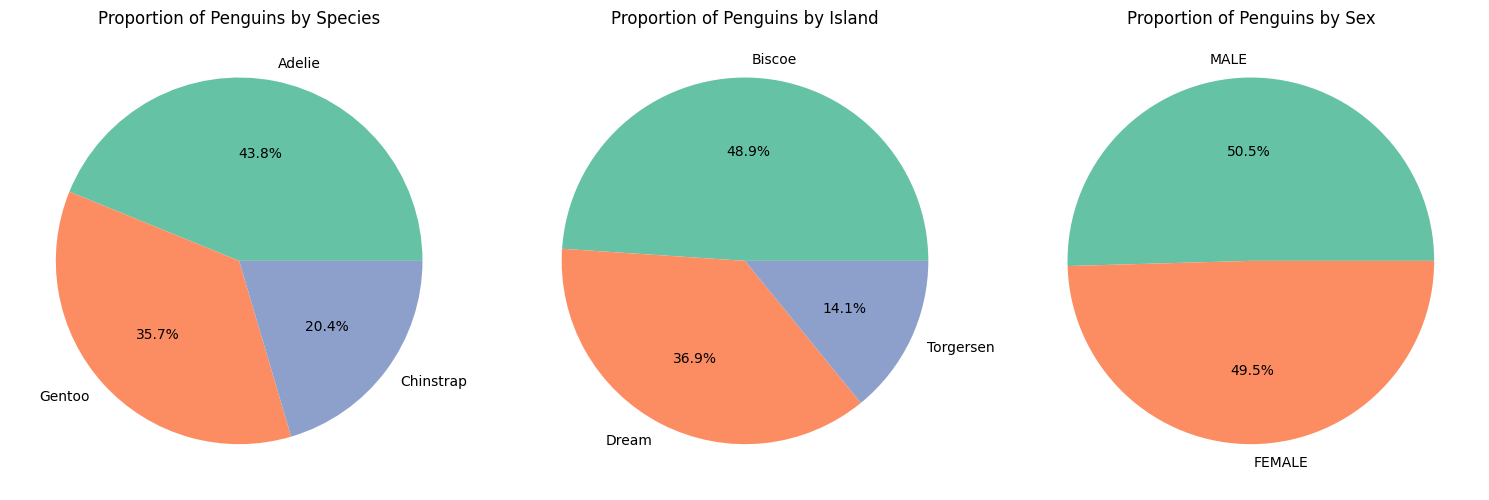

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].pie(species_counts, labels = species_counts.index, autopct='%.1f%%')
axes[1].pie(island_counts, labels = island_counts.index, autopct='%.1f%%')
axes[2].pie(sex_counts, labels = sex_counts.index, autopct='%.1f%%')

axes[0].set_title("Proportion of Penguins by Species")
axes[1].set_title("Proportion of Penguins by Island")
axes[2].set_title("Proportion of Penguins by Sex")

plt.tight_layout()
plt.show()

Corresponding to the count plots above, the pie charts further show the proportional composition of the dataset by species, island, and sex. They provide a percentage-based view of the same sample distribution.

### Penguin species on different islands

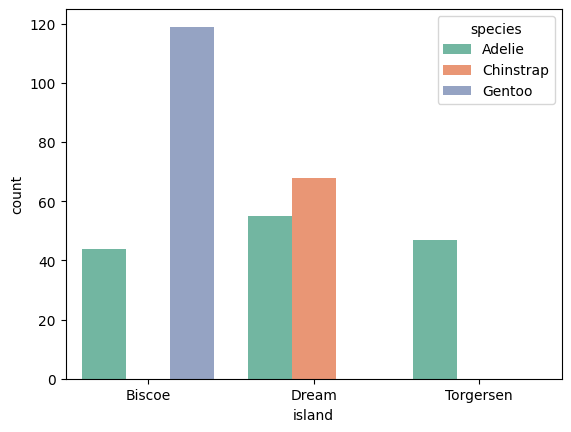

In [23]:
sns.countplot(cleaned_penguins, x = "island", hue = "species")
plt.show()

This count plot shows the distribution of penguin species across different islands. Gentoo penguins are only found on Biscoe, Chinstrap penguins are only found on Dream, while Adelie penguins appear on all three islands.

### Penguin sex on different islands

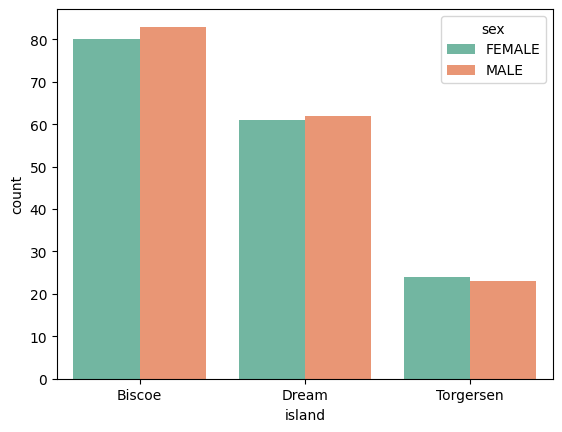

In [24]:
sns.countplot(cleaned_penguins, x = "island", hue = "sex")
plt.show()

This count plot compares the number of male and female penguins on each island. The sex distribution is generally balanced across the islands.

### Overall body measurement differences across species

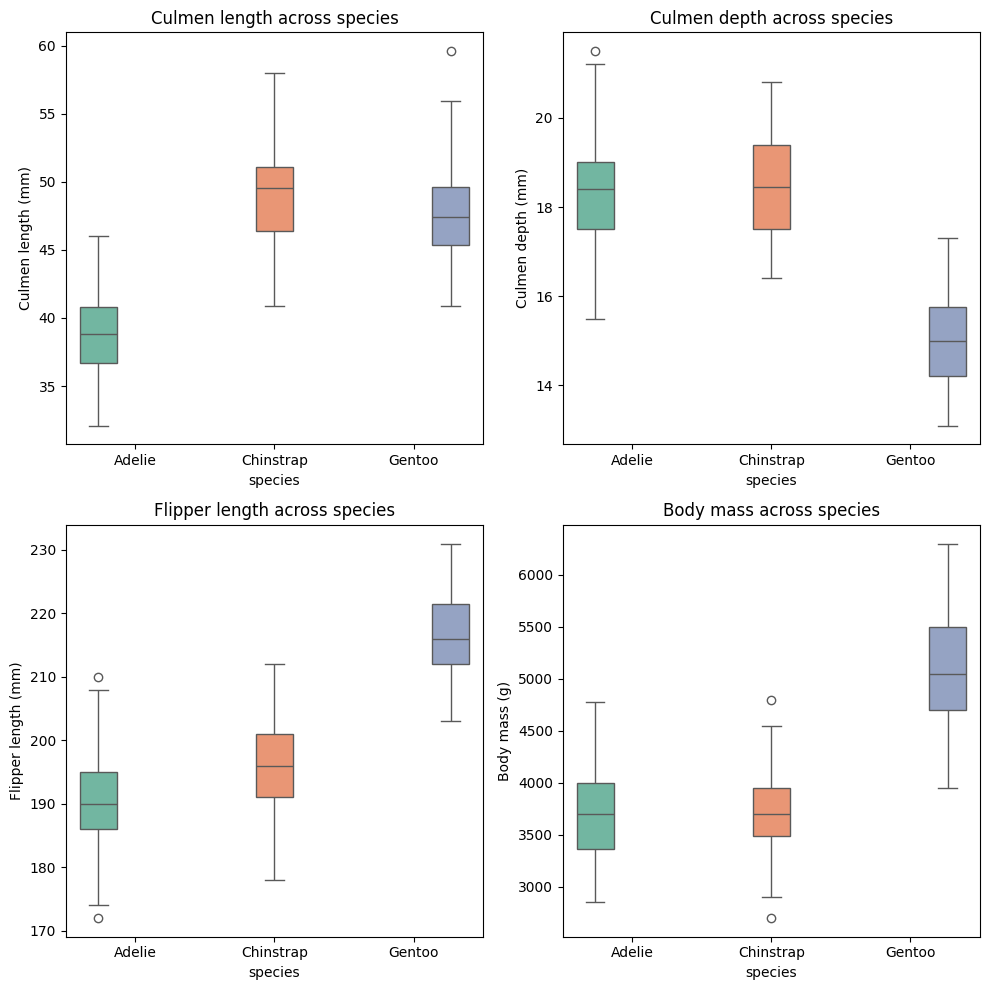

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

sns.boxplot(cleaned_penguins, x="species", y = "culmen_length_mm", hue="species", ax=axes[0, 0])
sns.boxplot(cleaned_penguins, x="species", y = "culmen_depth_mm", hue="species", ax=axes[0, 1])
sns.boxplot(cleaned_penguins, x="species", y = "flipper_length_mm", hue="species", ax=axes[1, 0])
sns.boxplot(cleaned_penguins, x="species", y = "body_mass_g", hue="species", ax=axes[1, 1])

axes[0, 0].set_ylabel("Culmen length (mm)")
axes[0, 1].set_ylabel("Culmen depth (mm)")
axes[1, 0].set_ylabel("Flipper length (mm)")
axes[1, 1].set_ylabel("Body mass (g)")

axes[0, 0].set_title("Culmen length across species")
axes[0, 1].set_title("Culmen depth across species")
axes[1, 0].set_title("Flipper length across species")
axes[1, 1].set_title("Body mass across species")

plt.tight_layout()
plt.show()

Box plots were used to compare body measurements across penguin species. Gentoo penguins generally have the longest flippers and highest body mass, while Chinstrap penguins tend to have longer culmens. Gentoo penguins have noticeably lower culmen depth than the other two species.

### Sex difference within species

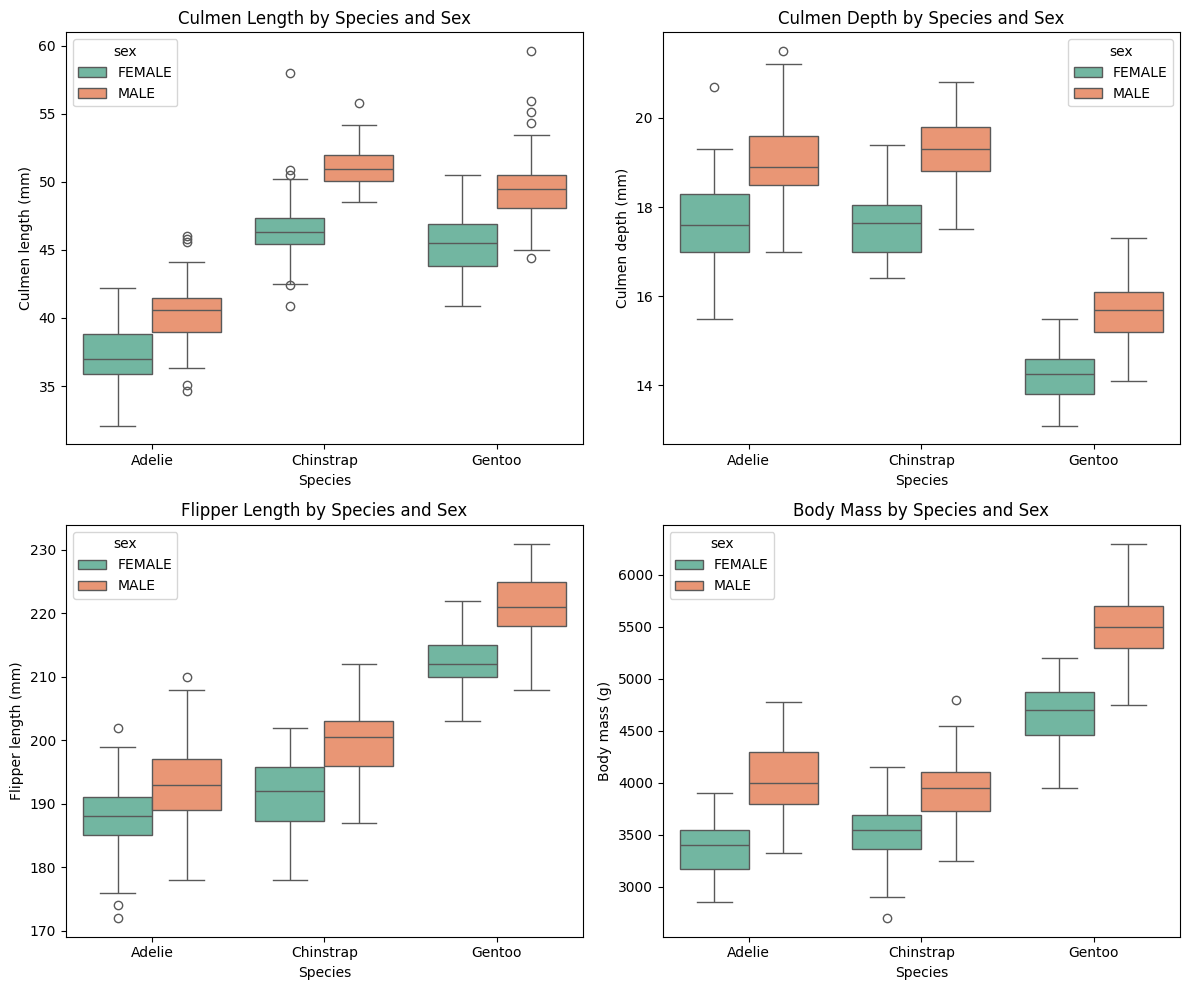

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.boxplot(
    cleaned_penguins,
    x="species",
    y="culmen_length_mm",
    hue="sex",
    ax=axes[0, 0]
)

sns.boxplot(
    data=cleaned_penguins,
    x="species",
    y="culmen_depth_mm",
    hue="sex",
    ax=axes[0, 1]
)

sns.boxplot(
    data=cleaned_penguins,
    x="species",
    y="flipper_length_mm",
    hue="sex",
    ax=axes[1, 0]
)

sns.boxplot(
    data=cleaned_penguins,
    x="species",
    y="body_mass_g",
    hue="sex",
    ax=axes[1, 1]
)

axes[0, 0].set_title("Culmen Length by Species and Sex")
axes[0, 1].set_title("Culmen Depth by Species and Sex")
axes[1, 0].set_title("Flipper Length by Species and Sex")
axes[1, 1].set_title("Body Mass by Species and Sex")

axes[0, 0].set_ylabel("Culmen length (mm)")
axes[0, 1].set_ylabel("Culmen depth (mm)")
axes[1, 0].set_ylabel("Flipper length (mm)")
axes[1, 1].set_ylabel("Body mass (g)")

for ax in axes.flat:
    ax.set_xlabel("Species")

plt.tight_layout()
plt.show()

Box plots were used to compare body measurements between male and female penguins within each species. Overall, male penguins tend to have larger culmen length, culmen depth, flipper length, and body mass than female penguins across the three species.

### Relationship between body measurements

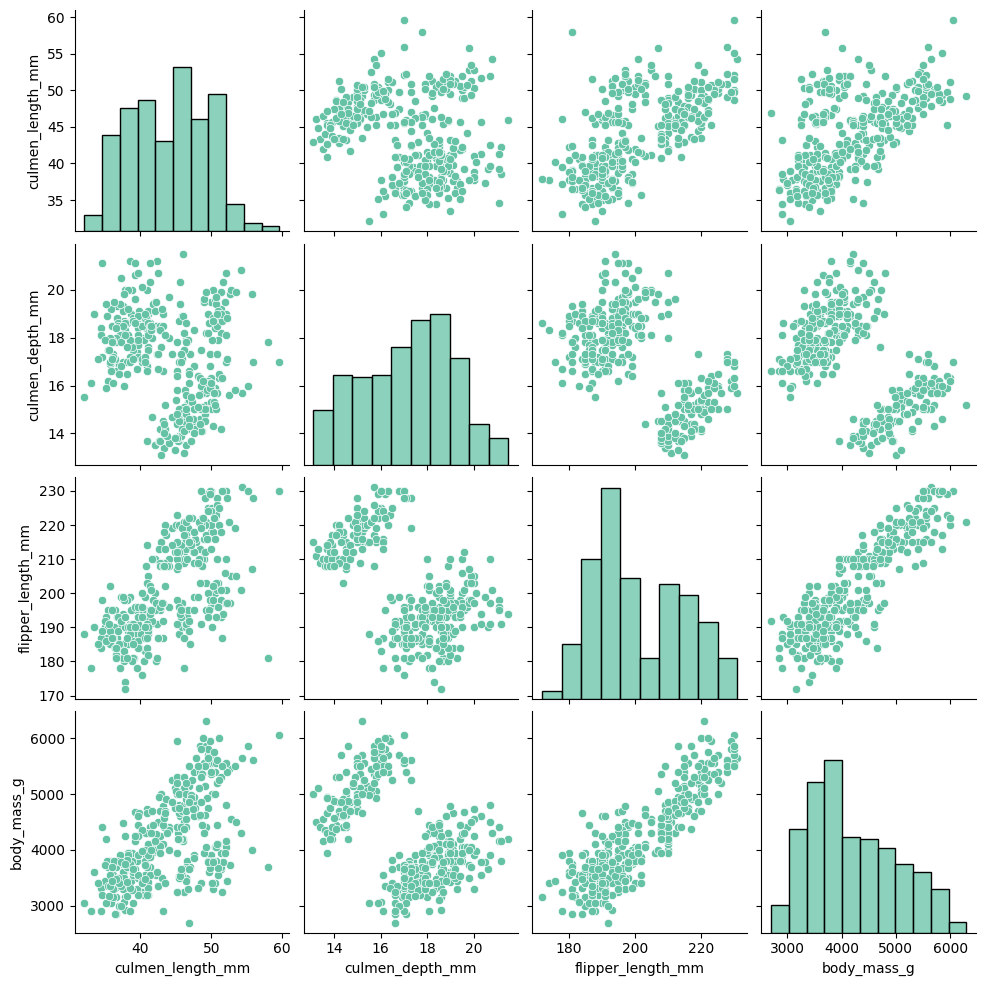

In [27]:
sns.pairplot(cleaned_penguins)
plt.show()

The pair plot shows the relationships among the four numerical body measurements. Several clear clusters can be observed, and some diagonal histograms appear skewed or bimodal, suggesting that the overall distributions may reflect the combined effects of different species, islands, or sexes. Therefore, further visualizations will separate the data by these categorical variables for more detailed analysis.

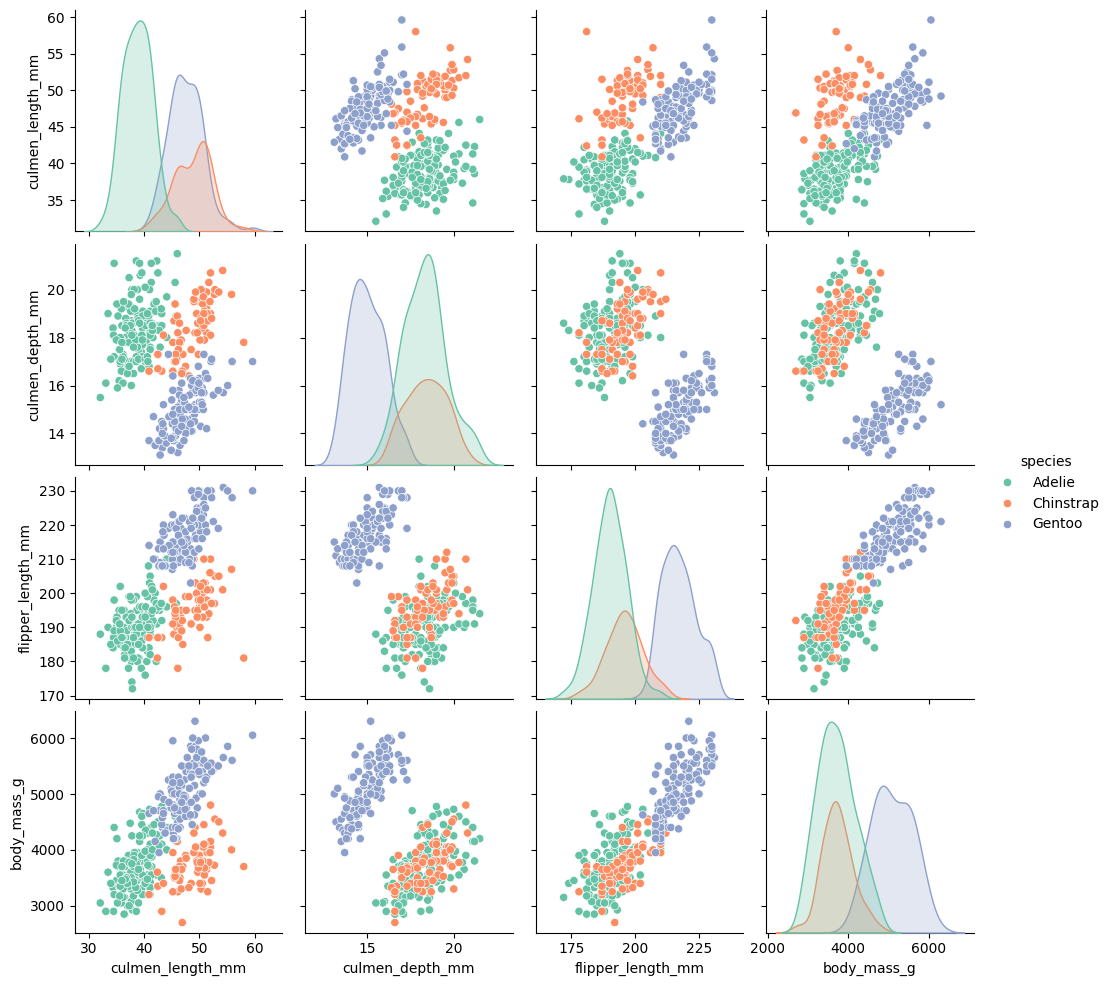

In [28]:
sns.pairplot(cleaned_penguins, hue="species")
plt.show()

The pair plot with species as the hue shows that the clusters are mainly separated by penguin species. Gentoo penguins have longer flippers and higher body mass, while Adelie penguins generally have shorter culmens. This suggests that species is an important factor in explaining differences in body measurements.

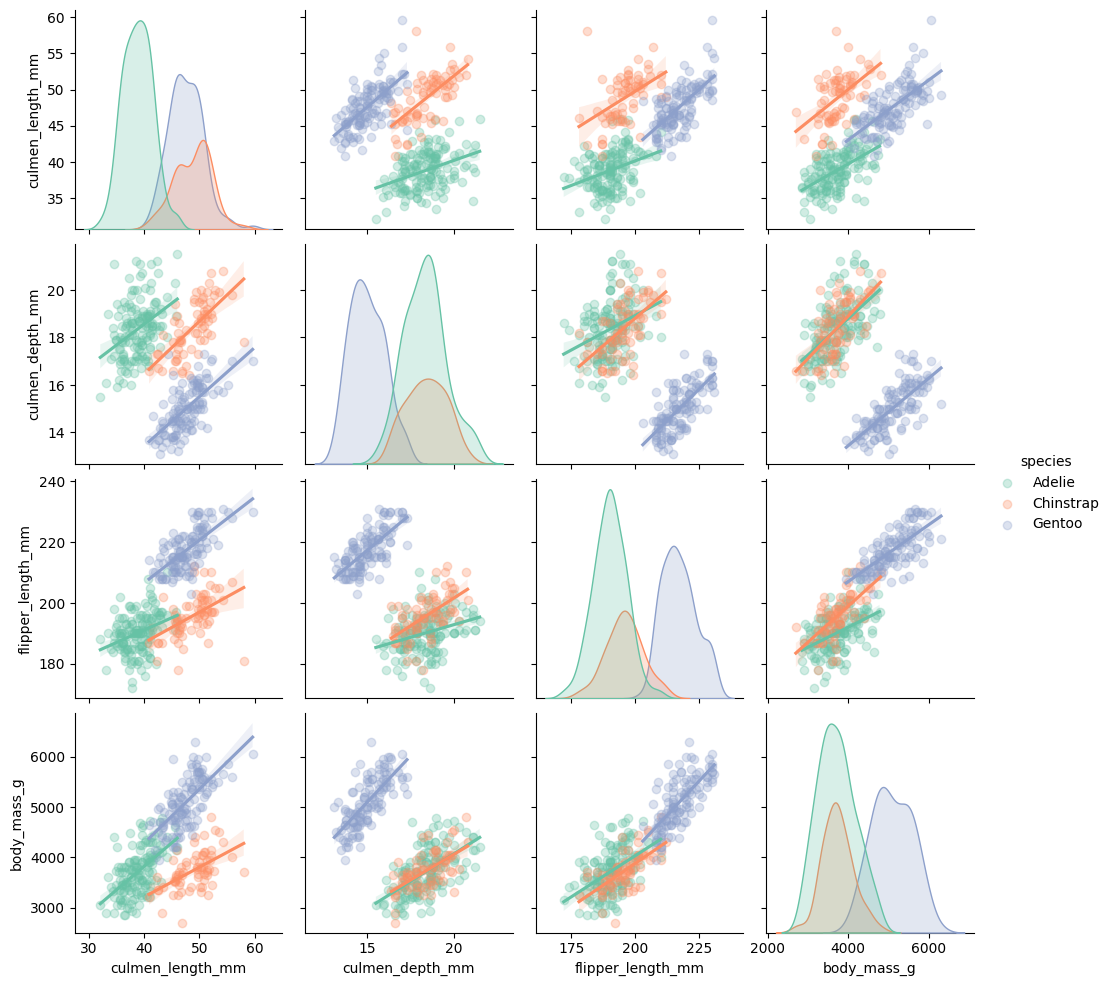

In [29]:
sns.pairplot(cleaned_penguins, hue="species", kind = 'reg', plot_kws = {'scatter_kws': {'alpha': 0.3}})
plt.show()

The pair plot with regression lines further shows the relationships between body measurements within each species. Most measurement pairs show positive relationships, and the regression patterns vary across species.

Since island and species are strongly related in this dataset, a pair plot grouped by island may mainly reflect species differences rather than independent island effects. Therefore, species was used as the main grouping variable for the pair plot analysis.

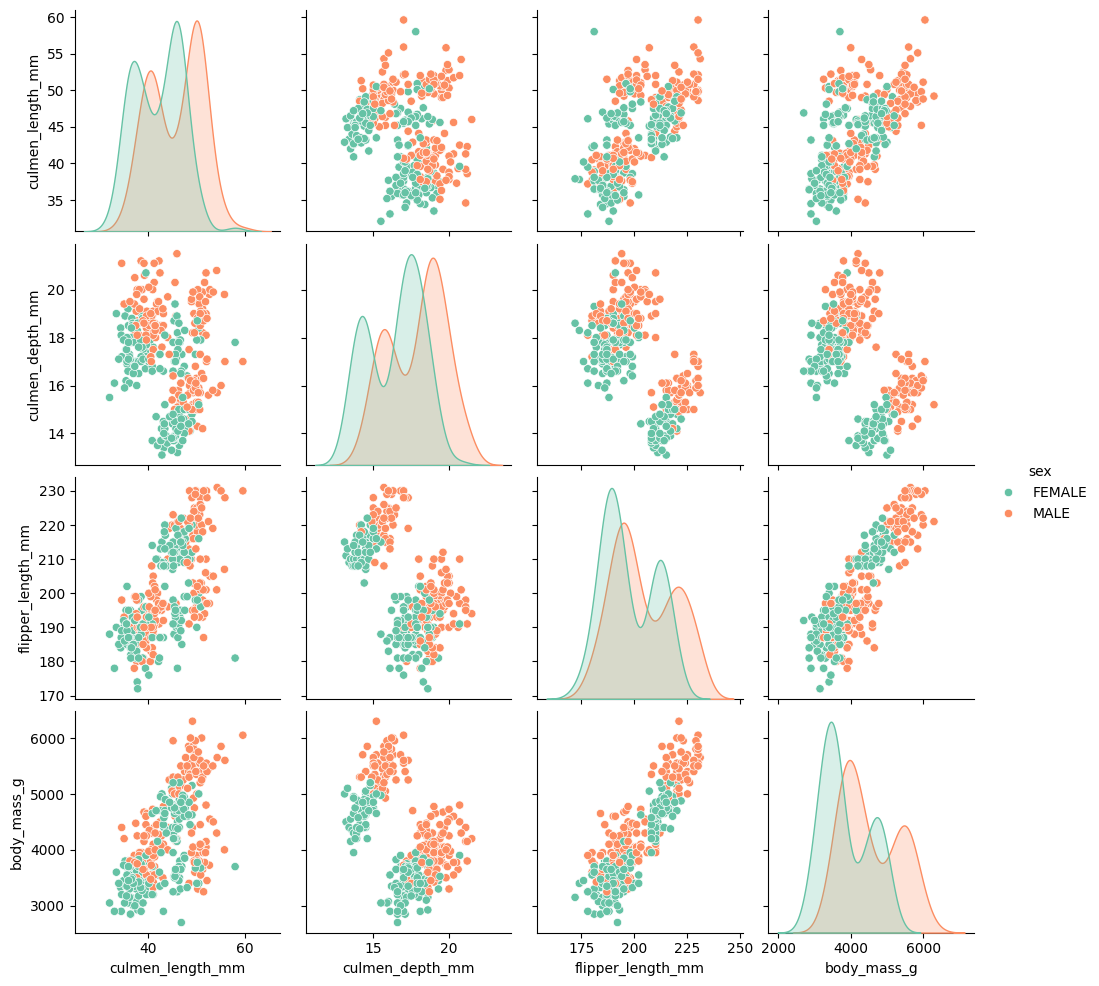

In [30]:
sns.pairplot(cleaned_penguins, hue="sex")
plt.show()

The pair plot with sex as the hue shows that male and female penguins have similar overall measurement patterns, but males generally have slightly larger body measurements than females. The clusters are still visible, suggesting that species differences may have a stronger effect than sex alone.

## Conclusion

This visualization analysis shows that penguin body measurements differ clearly across species. Gentoo penguins generally have longer flippers and higher body mass, while Chinstrap penguins tend to have longer culmens and Gentoo penguins show lower culmen depth. Male penguins also tend to have slightly larger body measurements than female penguins within each species.

The pair plots show clear clusters in the numerical measurements, and these clusters are mainly separated by species. Overall, species appears to be the main visual grouping factor in explaining the observed differences in penguin body measurements.